<a href="https://colab.research.google.com/github/KathituCodes/Diabetes-Prediction-Project/blob/main/Diabetes_Analysis_Complete_using_Supervised_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Diabetes Prediction Project
## Problem Statement
The goal of this project is to build a supervised machine learning model to predict whether a patient has diabetes based on diagnostic measurements like Plasma Glucose, BMI, and Age. Accurate prediction can help in early intervention and better health outcomes.

## 1. Data Loading
We start by loading the dataset and performing an initial inspection.

In [ ]:
# Step 1: Import necessary libraries
import pandas as pd                                     # Handles data tables and CSV files
import numpy as np                                      # Performs fast math and works with number arrays
from sklearn.linear_model import LogisticRegression    # A model used to predict categories (e.g., Yes/No)
from sklearn.model_selection import train_test_split, cross_val_score # Splits data into "practice" and "test" sets
from sklearn.preprocessing import StandardScaler        # Scales data so all numbers are on a similar range
from sklearn.neighbors import KNeighborsClassifier      # A model that classifies data based on similar neighbors
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier # it is used to build a "forest" of many decision trees that work together to provide more accurate and reliable predictions than any single tree could on its own
from sklearn.metrics import classification_report, confusion_matrix # Shows detailed breakdown of model errors
from sklearn import metrics                             # Tools to measure model performance
from sklearn.metrics import accuracy_score              # Calculates the percentage of correct predictions
import seaborn as sns                                   # Creates polished, statistical charts
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv('diabetes.csv')



In [ ]:
# Display the first 10 rows
df.head(20)



,PatientID,Pregnancies,PlasmaGlucose,DiastolicBloodPressure,TricepsThickness,SerumInsulin,BMI,DiabetesPedigree,Age,Diabetic
0,1354778,0,171,80,34,23,43.509726,1.213191,21,0
1,1147438,8,92,93,47,36,21.240576,0.158365,23,0
2,1640031,7,115,47,52,35,41.511523,0.079019,23,0
3,1883350,9,103,78,25,304,29.582192,1.282870,43,1
4,1424119,1,85,59,27,35,42.604536,0.549542,22,0
5,1619297,0,82,92,9,253,19.724160,0.103424,26,0
6,1660149,0,133,47,19,227,21.941357,0.174160,21,0
7,1458769,0,67,87,43,36,18.277723,0.236165,26,0
8,1201647,8,80,95,33,24,26.624929,0.443947,53,1
9,1403912,1,72,31,40,42,36.889576,0.103944,26,0


In [ ]:
# Display data information
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   PatientID               15000 non-null  int64  
 1   Pregnancies             15000 non-null  int64  
 2   PlasmaGlucose           15000 non-null  int64  
 3   DiastolicBloodPressure  15000 non-null  int64  
 4   TricepsThickness        15000 non-null  int64  
 5   SerumInsulin            15000 non-null  int64  
 6   BMI                     15000 non-null  float64
 7   DiabetesPedigree        15000 non-null  float64
 8   Age                     15000 non-null  int64  
 9   Diabetic                15000 non-null  int64  
dtypes: float64(2), int64(8)
memory usage: 1.1 MB
None


In [ ]:
df.describe()

,PatientID,Pregnancies,PlasmaGlucose,DiastolicBloodPressure,TricepsThickness,SerumInsulin,BMI,DiabetesPedigree,Age,Diabetic
count,1.500000e+04,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,1.502922e+06,3.224533,107.856867,71.220667,28.814000,137.852133,31.509646,0.398968,30.137733,0.333333
std,2.892534e+05,3.391020,31.981975,16.758716,14.555716,133.068252,9.759000,0.377944,12.089703,0.471420
min,1.000038e+06,0.000000,44.000000,24.000000,7.000000,14.000000,18.200512,0.078044,21.000000,0.000000
25%,1.252866e+06,0.000000,84.000000,58.000000,15.000000,39.000000,21.259887,0.137743,22.000000,0.000000
50%,1.505508e+06,2.000000,104.000000,72.000000,31.000000,83.000000,31.767940,0.200297,24.000000,0.000000
75%,1.755205e+06,6.000000,129.000000,85.000000,41.000000,195.000000,39.259692,0.616285,35.000000,1.000000
max,1.999997e+06,14.000000,192.000000,117.000000,93.000000,799.000000,56.034628,2.301594,77.000000,1.000000


## 2. Data Cleaning
Checking for missing values and duplicates to ensure data quality.

In [ ]:
# Check for missing values
print('Missing Values:\n', df.isnull().sum())

# Check for duplicates
print('\nDuplicate Rows:', df.duplicated().sum())

Missing Values:
 PatientID                 0
Pregnancies               0
PlasmaGlucose             0
DiastolicBloodPressure    0
TricepsThickness          0
SerumInsulin              0
BMI                       0
DiabetesPedigree          0
Age                       0
Diabetic                  0
dtype: int64

Duplicate Rows: 0


## 3. Outlier Management
Outliers can skew the results of many algorithms. We visualize them using boxplots and then handle them using the Interquartile Range (IQR) method.

## **Method 1 for checking if outliers exist in the data**

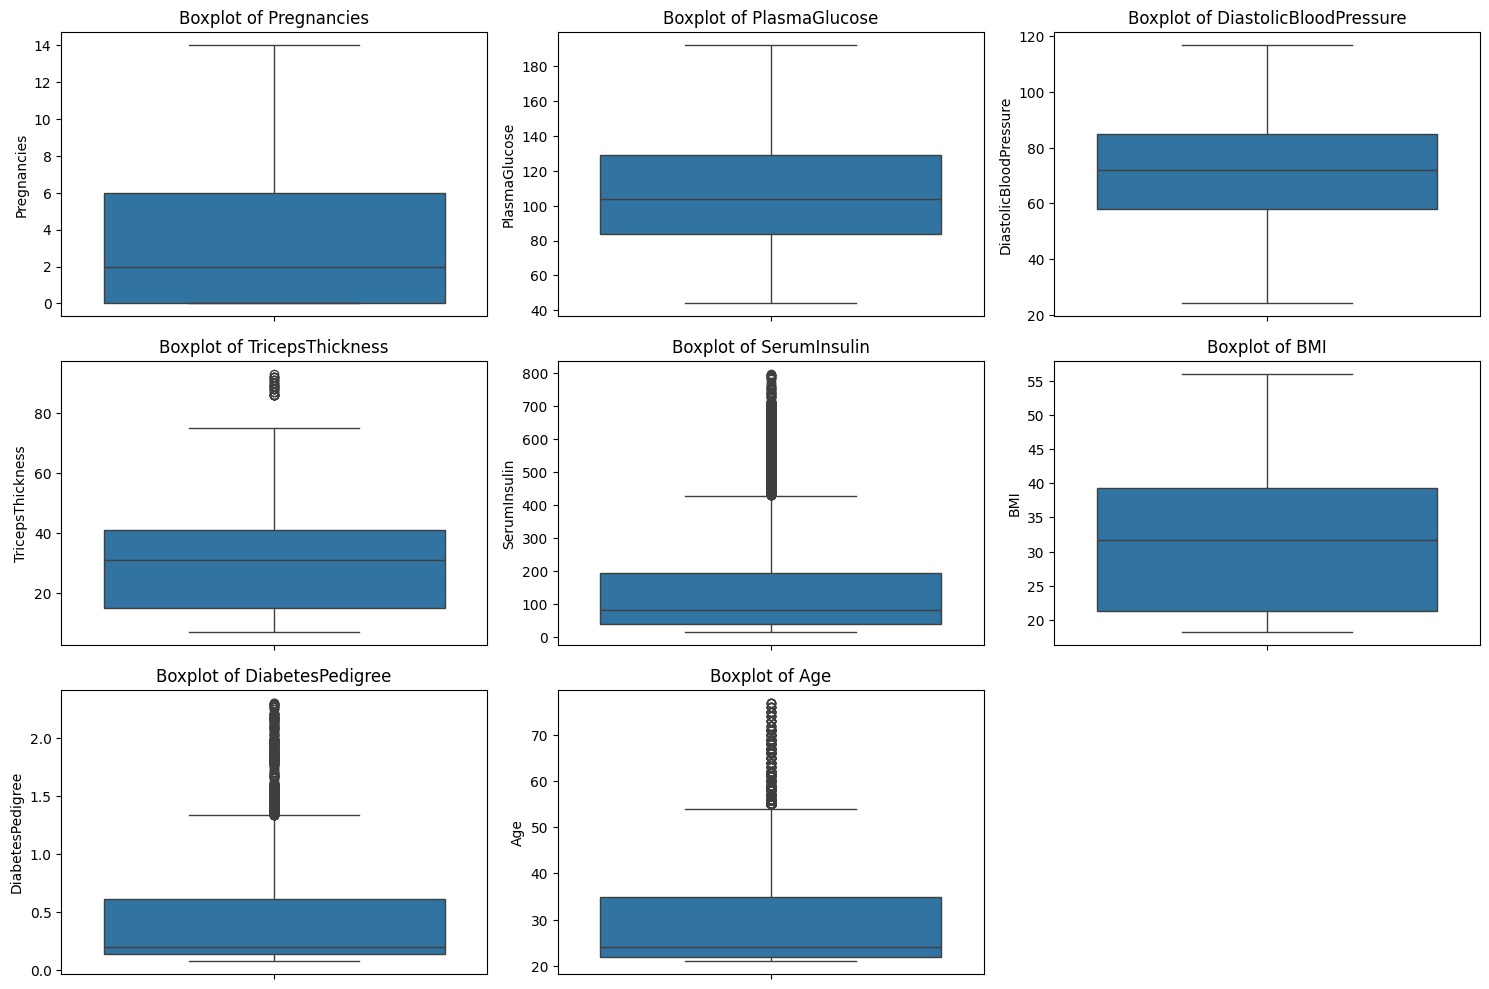

In [ ]:
# Visualize outliers using boxplots
num_cols = df.select_dtypes(include=[np.number]).drop(columns=['PatientID', 'Diabetic']).columns  # # Create a list of column names that contain numbers, while removing 'PatientID' (an ID) and 'Diabetic' (the target)
plt.figure(figsize=(15, 10))
for i, col in enumerate(num_cols, 1): # # Loop through each numerical column name; 'enumerate' gives us both the index (i) starting at 1 and the column name (col)
    plt.subplot(3, 3, i)  # # Create a grid of plots with 3 rows and 3 columns, and select the 'i-th' empty slot for the current plot
    sns.boxplot(y=df[col])  # Draw a boxplot for the current column's data to visually check for outliers and data distribution
    plt.title(f'Boxplot of {col}')
plt.tight_layout()  # # Automatically adjust the padding between subplots so that titles and labels don't overlap
plt.show()

## **Method 2 for checking for Outliers in the data**

In [ ]:
# Lets check for outliers using IQR in the numerical columns
# What IQR does is it filters the dataset to find the rows that fall outside the fences of Q3 - Q1
# Defines the specific columns you want to check (Quantity, Price,Total Spent)
num_cols = df.select_dtypes(include=[np.number]).drop(columns=['PatientID', 'Diabetic']).columns  # # Create a list of column names that contain numbers, while removing 'PatientID' (an ID) and 'Diabetic' (the target)
for col in num_cols:
  Q1 = df[col].quantile(0.25)
  Q3 = df[col].quantile(0.75)
  IQR = Q3 - Q1
  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR
  outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
  print(f"number of outliers in {col}: {len(outliers)}")

number of outliers in Pregnancies: 0
number of outliers in PlasmaGlucose: 0
number of outliers in DiastolicBloodPressure: 0
number of outliers in TricepsThickness: 31
number of outliers in SerumInsulin: 666
number of outliers in BMI: 0
number of outliers in DiabetesPedigree: 475
number of outliers in Age: 1019


In [ ]:
# 1. TricepsThickness  (31 high-end outliers, upper fence = 80 mm)
# ══════════════════════════════════════════════════════════════════════════════
# Situation : 31 values exceed 80 mm (max = 93 mm). Triceps skinfold > 80 mm
#             is physiologically possible in severe obesity but rare.
#             Distribution is moderately right-skewed.
# Strategy  : Winsorize (cap) at the 99th percentile.
#             Why winsorize instead of drop? Only 31 rows (0.2% of 15k).
#             Capping preserves the rows while limiting undue influence on
#             distance-based and linear models.
# ──────────────────────────────────────────────────────────────────────────────

TRICEPS_CAP = df["TricepsThickness"].quantile(0.99)

df["TricepsThickness_clean"] = df["TricepsThickness"].clip(upper=TRICEPS_CAP)

print(f"\nTricepsThickness:")
print(f"  Cap value (99th pct): {TRICEPS_CAP:.1f} mm")
print(f"  Rows capped: {(df['TricepsThickness'] > TRICEPS_CAP).sum()}")
print(f"  Before — max: {df['TricepsThickness'].max()}")
print(f"  After  — max: {df['TricepsThickness_clean'].max()}")


TricepsThickness:
  Cap value (99th pct): 56.0 mm
  Rows capped: 131
  Before — max: 93
  After  — max: 56


## **Understanding Log Tranformation and why it is used**

### The Problem — a "bully" in the data

Imagine you have a class of 10 students and you ask them how much pocket money they get per week:

```
20, 25, 18, 22, 30, 19, 24, 21, 23, 500
```

One student gets **500** while everyone else gets around **20**.

Now if you calculate the average — it comes out to **70**. But that doesn't represent anyone in the class. The one student with 500 **bullied** the result and pulled the average way up.

That's exactly what happens in your SerumInsulin column. Most patients have insulin around 100, but a few have 799. Those few patients bully the model.

---

### What log transformation does — shrinking the bully

Log transformation is like applying a **shrinking penalty that hits big numbers much harder than small numbers.**

```
20  → 3.0      (reduced a little)
100 → 4.6      (reduced a little)
500 → 6.2      (reduced a LOT)
799 → 6.7      (reduced a LOT)
```

The student with 500 no longer dominates. Everyone is now on a more **level playing field** — small values spread out, big values shrink in.

---

### The outcome

| | Before | After |
|---|---|---|
| Smallest value | 14 | 2.6 |
| Typical value | ~100 | ~4.6 |
| Biggest value | 799 | 6.7 |
| Skewness | 1.77 (lopsided) | 0.03 (balanced) |

The data went from **heavily lopsided** to **nearly perfectly balanced** — without deleting a single patient.

---

### One line summary for your students

> Log transformation is used when a few very large values are distorting the data. It shrinks the big numbers down so they stop bullying the rest of the dataset, giving your model a fair and balanced view of all patients.

In [ ]:
# 2. SerumInsulin  (666 high-end outliers, upper fence = 429 μU/mL)
# ══════════════════════════════════════════════════════════════════════════════
# Situation : 666 values exceed 429 μU/mL (max = 799). Fasting insulin above
#             ~300 μU/mL is very unusual and likely indicates diabetic crisis,
#             PCOS with severe resistance, or insulinoma. The column is heavily
#             right-skewed (IQR = 156, range spans 785 units).
# Strategy  : Log-transform THEN winsorize.
#             Step 1 — log1p compresses the long right tail and makes the
#             distribution more symmetric, helping linear/distance models.
#             Step 2 — winsorize the log-transformed column at 99th pct to
#             handle the most extreme post-transform residuals.
# ──────────────────────────────────────────────────────────────────────────────

# Step 1: log-transform (log1p handles 0 safely, though none exist here)
df["SerumInsulin_log"] = np.log1p(df["SerumInsulin"])

# Step 2: winsorize the log-transformed values
LOG_INS_CAP = df["SerumInsulin_log"].quantile(0.99)
df["SerumInsulin_clean"] = df["SerumInsulin_log"].clip(upper=LOG_INS_CAP)

print(f"\nSerumInsulin:")
print(f"  Original  — skewness: {df['SerumInsulin'].skew():.2f}, max: {df['SerumInsulin'].max()}")
print(f"  After log — skewness: {df['SerumInsulin_log'].skew():.2f}, max: {df['SerumInsulin_log'].max():.3f}")
print(f"  Log cap (99th pct):   {LOG_INS_CAP:.3f}")
print(f"  Rows capped after log: {(df['SerumInsulin_log'] > LOG_INS_CAP).sum()}")



SerumInsulin:
  Original  — skewness: 1.77, max: 799
  After log — skewness: 0.03, max: 6.685
  Log cap (99th pct):   6.474
  Rows capped after log: 149


In [ ]:
 # 3. DiabetesPedigree  (475 high-end outliers, upper fence ≈ 1.33)
# ══════════════════════════════════════════════════════════════════════════════
# Situation : 475 values exceed 1.33 (max ≈ 2.30). The pedigree function
#             ranges from 0 to ∞ in theory; values above 1.5 are very high
#             but valid — they indicate a dense family history of diabetes.
#             The column is right-skewed (long tail of high-risk patients).
# Strategy  : Log-transform to compress the right tail.
#             Why not drop/cap? High pedigree values are clinically meaningful
#             (strong predictor of diabetes). Removing them would bias the
#             model toward under-detecting high-hereditary-risk patients.
#             Log-transform retains the ordering while reducing leverage.
# ──────────────────────────────────────────────────────────────────────────────

df["DiabetesPedigree_log"] = np.log1p(df["DiabetesPedigree"])

print(f"\nDiabetesPedigree:")
print(f"  Original  — skewness: {df['DiabetesPedigree'].skew():.2f}, max: {df['DiabetesPedigree'].max():.3f}")
print(f"  After log — skewness: {df['DiabetesPedigree_log'].skew():.2f}, max: {df['DiabetesPedigree_log'].max():.3f}")



DiabetesPedigree:
  Original  — skewness: 1.68, max: 2.302
  After log — skewness: 1.15, max: 1.194


In [ ]:
# FINAL: Assemble clean modelling dataframe
# ══════════════════════════════════════════════════════════════════════════════

df_clean = df[[
    "Pregnancies",                  # unchanged
    "PlasmaGlucose",               # unchanged
    "DiastolicBloodPressure",      # unchanged (use DBP_extreme_flag optionally)
    "TricepsThickness_clean",      # winsorized at 99th pct
    "SerumInsulin_clean",          # log-transformed + winsorized
    "BMI",                         # unchanged
    "DiabetesPedigree_log",        # log-transformed
    "Age",                         # unchanged (Age_band available as extra feature)
    "Diabetic",                    # target
]].copy()

print("\n=== Final modelling dataframe ===")



=== Final modelling dataframe ===


In [ ]:
# Observe the updated statisticall summary of the data after dealing with outliers
df_clean.describe()


,Pregnancies,PlasmaGlucose,DiastolicBloodPressure,TricepsThickness_clean,SerumInsulin_clean,BMI,DiabetesPedigree_log,Age,Diabetic
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,3.224533,107.856867,71.220667,28.700000,4.492834,31.509646,0.305560,30.137733,0.333333
std,3.391020,31.981975,16.758716,14.239936,0.966274,9.759000,0.235106,12.089703,0.471420
min,0.000000,44.000000,24.000000,7.000000,2.708050,18.200512,0.075148,21.000000,0.000000
25%,0.000000,84.000000,58.000000,15.000000,3.688879,21.259887,0.129047,22.000000,0.000000
50%,2.000000,104.000000,72.000000,31.000000,4.430817,31.767940,0.182569,24.000000,0.000000
75%,6.000000,129.000000,85.000000,41.000000,5.278115,39.259692,0.480130,35.000000,1.000000
max,14.000000,192.000000,117.000000,56.000000,6.473891,56.034628,1.194405,77.000000,1.000000


In [ ]:
# Check to see if the shape of our data has been affected
print(f"\nShape: {df_clean.shape}")

# Save the cleaned data to a CSV file
df_clean.to_csv("diabetes_clean.csv", index=False)   # adjust path as needed
print("\nSaved → diabetes_clean.csv")


Shape: (15000, 9)

Saved → diabetes_clean.csv


## 4. Exploratory Data Analysis (EDA)


Visualizing relationships between features and the target variable.

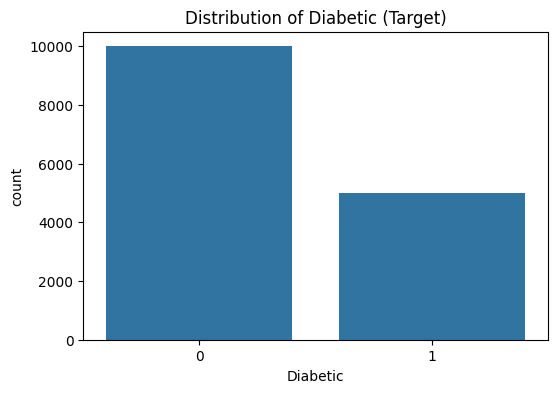

In [ ]:
# Distribution plot for the target variable
plt.figure(figsize=(6, 4))
sns.countplot(x='Diabetic', data=df_clean)
plt.title('Distribution of Diabetic (Target)')
plt.show()

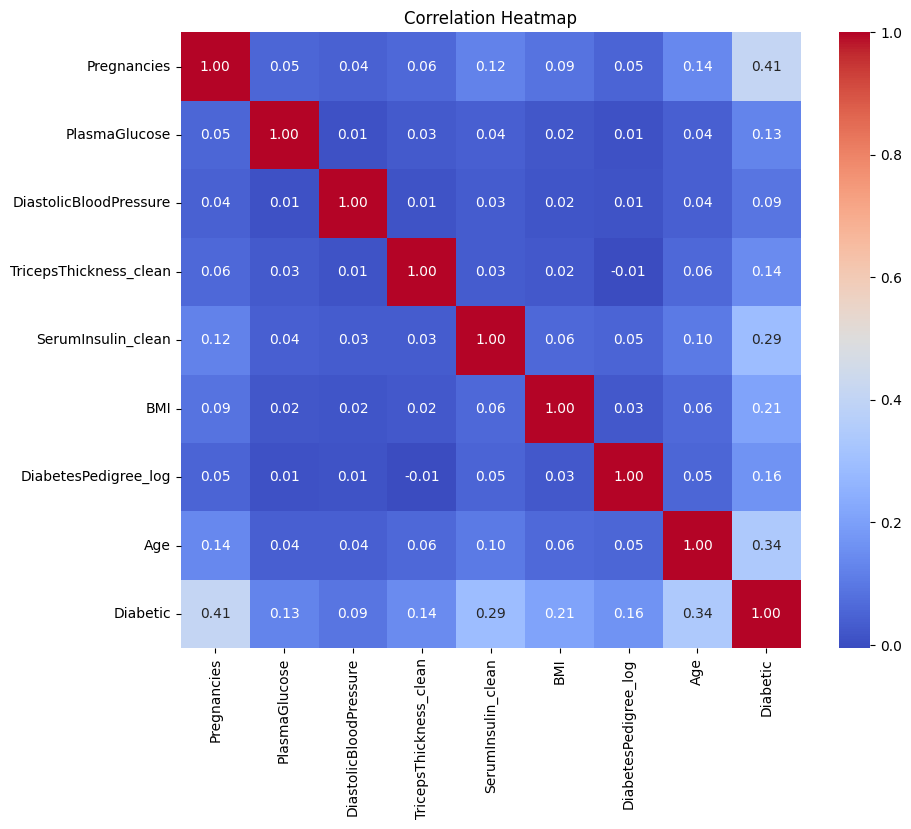

In [ ]:
# Correlation Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df_clean.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

## 5. Feature Engineering & Scaling
Separating features and target, then scaling the data for models like KNN and Logistic Regression.

# **Building the Logistic Regression Model**

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Separate features and target
X = df_clean.drop(columns=['Diabetic'])  # Create the input features (X) by removing 'PatientID' (useless for prediction) and 'Diabetic' (which is the answer)
y = df_clean['Diabetic']  # Create the target variable (y) which contains only the 'Diabetic' column—the labels we want to predict

# Split the data into two sets: 80% for the model to study (training) and 20% for a final exam (testing)
# stratify=y keeps the class balance similar in both splits
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify =y) # 'random_state=42' ensures that every time you run this, you get the exact same split

# Initialize the StandardScaler, which adjusts data so it has a mean of 0 and a standard deviation of 1
scaler = StandardScaler()

print("Data scuessfully split and scaled")

Data scuessfully split and scaled


In [ ]:
# Calculate the scaling parameters (mean and variance) from the training data AND apply the transformation to it
# We call this 'fit_transform' because the model "learns" the scale from this specific set
X_train_scaled = scaler.fit_transform(X_train)

# Apply the exact same scaling to the test data using the parameters learned from the training set
# We use only 'transform' here to prevent "data leakage" (we don't want the test data to influence the scaling)
X_test_scaled = scaler.transform(X_test)

print('Data split and scaling complete.')

Data split and scaling complete.


# **Applying Logistiic Regression**

In [ ]:
# Imagine trying to crack a 4-digit code. max_iter=1000 is like telling the computer:
# "You have 1,000 attempts to find the right combination. If you find it on attempt 450,
# you can stop early. If you reach 1,000 and still haven't found it, stop anyway and tell me your best guess."

# Build and train (fit) a Logistic Regression model
# Logistic Regression is a classification algorithm for yes/no outcomes.
logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000)

In [ ]:
# Make some predictions and assess how our model performs
training_predictions = logreg.predict(X_train_scaled)
testing_predictions = logreg.predict(X_test_scaled)

# print the results of the training and testing predictions
print("Training Predictions:", training_predictions)
print("Testing Predictions:", testing_predictions)

Training Predictions: [0 1 0 ... 0 1 0]
Testing Predictions: [0 0 0 ... 0 0 0]


In [ ]:
# print the models accuracy score
print("Training Accuracy:", accuracy_score(y_train, training_predictions))

Training Accuracy: 0.7938333333333333


In [ ]:
# print classification report with the models accuracy score

print("Testing Classification Report:")
print(classification_report(y_test, testing_predictions))


Testing Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.88      0.85      2000
           1       0.72      0.61      0.66      1000

    accuracy                           0.79      3000
   macro avg       0.77      0.75      0.76      3000
weighted avg       0.79      0.79      0.79      3000






### What your model was tested on
```
Class 0 = Not Diabetic → 2,000 patients
Class 1 = Diabetic     → 1,000 patients
Total                  → 3,000 patients
```

---

### Overall Accuracy
Your model got **79% of all 3,000 patients correct**. Sounds decent, but accuracy alone is misleading here because you have twice as many non-diabetic patients — the model can "cheat" by just predicting 0 more often.

---

### For Non-Diabetic patients (Class 0)
```
Precision = 0.82   
Recall    = 0.88   
F1        = 0.85   
```

**Precision (0.82)** — When the model said "not diabetic", it was right 82% of the time.

**Recall (0.88)** — Out of all 2,000 actual non-diabetic patients, the model correctly caught 88% of them.

The model is **good at identifying healthy patients.** Not surprising — there are more of them to learn from.

---

### For Diabetic patients (Class 1) ⚠️
```
Precision = 0.72   
Recall    = 0.61   
F1        = 0.66   
```

**Precision (0.72)** — When the model said "diabetic", it was right 72% of the time.

**Recall (0.61)** — Out of all 1,000 actual diabetic patients, the model only caught **61% of them**.

This means **390 diabetic patients were told they are healthy** when they are not. In a medical context this is the most dangerous number in the entire report — these are called **false negatives.**

---

### The core problem — Class Imbalance

Your dataset has **2,000 non-diabetic vs 1,000 diabetic** patients. The model saw twice as many non-diabetic examples during training, so it learned to favour predicting Class 0. That's why Class 0 performance is strong and Class 1 is weak.

---

### Summary table in plain English

| Metric | Value | What it means |
|---|---|---|
| Overall accuracy | 79% | Correct on 2,370 of 3,000 patients |
| Diabetic recall | 61% | Missed 390 sick patients |
| Non-diabetic recall | 88% | Correctly cleared 1,760 healthy patients |
| F1 for diabetic | 0.66 | Weak — model struggles with the minority class |

---

### What you should do next

The **recall for diabetic patients (0.61) is too low** for a medical model. Missing a diabetic patient is far more costly than a false alarm. You should:

1. **Balance your classes** — use oversampling (SMOTE) or undersampling before training
2. **Lower the decision threshold** — instead of predicting diabetic at 50% probability, try 30–40% to catch more diabetic patients
3. **Prioritise recall over precision** for Class 1 — in healthcare, it's better to flag someone healthy for further tests than to send a sick person home

# Build and train a KNN model
# K-Nearest Neighbors (KNN)

In KNN, we predict a new example by looking at the **K closest examples** in the training data.

**Important:** KNN uses **distance**, so we must **scale** the features (otherwise a big-number feature like GMAT can dominate the distance).

In [ ]:
# Step 1
# Build a KNN model using a Pipeline (scaling + KNN in one safe workflow)
# Pipeline helps us avoid mistakes: it always scales the data before KNN measures distance.
from sklearn.pipeline import Pipeline

knn_pipeline = Pipeline([
    ("scaler", StandardScaler()),                # Step 1: scale features
    ("knn", KNeighborsClassifier(n_neighbors=5))  # Step 2: KNN classifier (start with K=5)
])

In [ ]:
""""
Remember to avoid double-scaling the data. Our pipeline already includes a StandardScaler internally,
so you do not need to  pass X_train_scaled and X_test_scaled (data that's already been scaled externally).
We can simply pass the raw X_train and X_test into the pipeline, and let the pipeline handle the scaling
itself. This is actually the whole point of using a Pipeline.

"""""

In [ ]:
# Step 2
# Train (fit) the KNN pipeline and make predictions on the test set
knn_pipeline.fit(X_train, y_train)          # store training data (after scaling rules are learned)
y_pred_knn = knn_pipeline.predict(X_test)   # predict diebetic(1) or not diabetic(0) for test data

# Show a few predictions
y_pred_knn[:10]

array([1, 0, 0, 1, 0, 0, 1, 1, 1, 0])

In [ ]:
# Evaluate the KNN model with accuracy + a classification report
knn_test_accuracy = accuracy_score(y_test, y_pred_knn)
print("KNN Test Accuracy:", round(knn_test_accuracy, 3))

print("\nClassification Report (KNN):")
print(classification_report(y_test, y_pred_knn))

KNN Test Accuracy: 0.879

Classification Report (KNN):
              precision    recall  f1-score   support

           0       0.89      0.93      0.91      2000
           1       0.85      0.77      0.81      1000

    accuracy                           0.88      3000
   macro avg       0.87      0.85      0.86      3000
weighted avg       0.88      0.88      0.88      3000



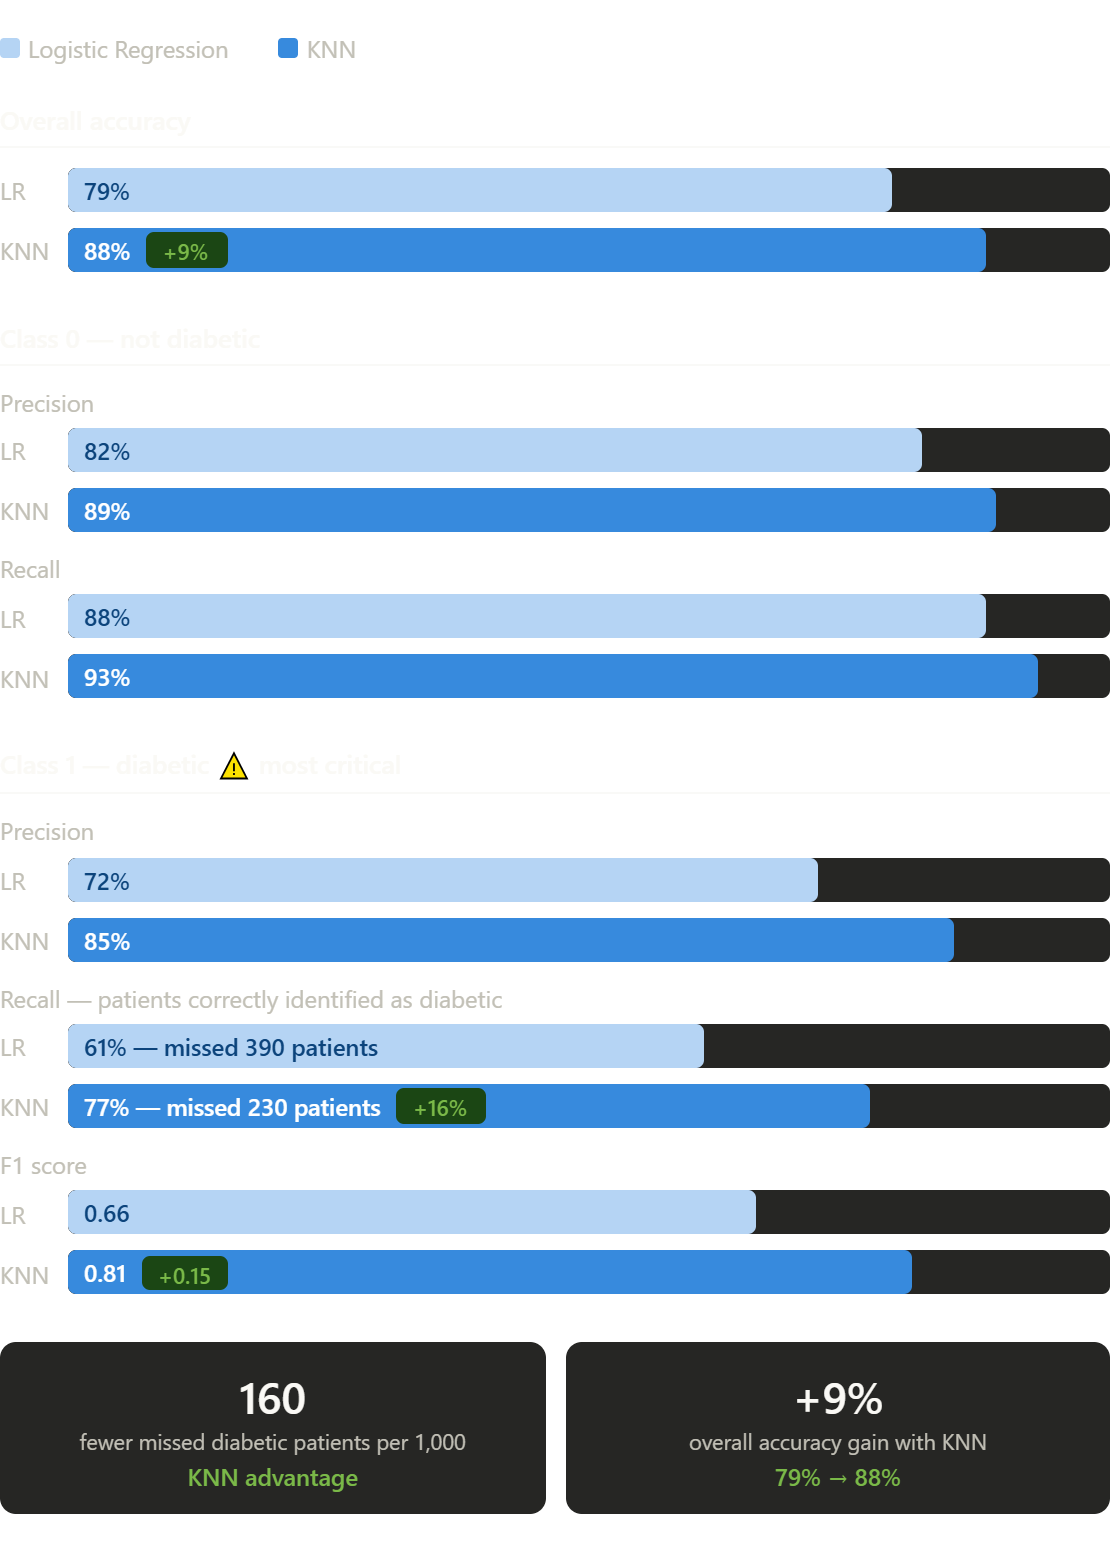


**KNN clearly wins on every single metric.** Overall accuracy jumped from 79% (Logistic Regression) to 88% (KNN). More importantly, the diabetic recall — the most critical number — improved from a concerning 61% to 77%. That means KNN correctly catches 160 more diabetic patients out of every 1,000 that Logistic Regression was missing.---

### Why did KNN outperform Logistic Regression here?

**Logistic Regression** draws a straight line to separate diabetic from non-diabetic patients. If the relationship between your features and diabetes is curved or complex, a straight line will always miss some patterns.

**KNN** doesn't draw any line at all. It looks at the K nearest patients in the data and says "most of your neighbours are diabetic, so you probably are too." This makes it naturally better at capturing complex, non-linear boundaries — which is exactly what diabetes risk tends to be.

---

### The one caution about KNN

KNN's weakness is that it is slow and memory-heavy on large datasets because it has to measure the distance to every training point at prediction time. With your 15,000 rows it's fine, but at 1 million+ rows Logistic Regression would be the more practical choice despite its lower accuracy.

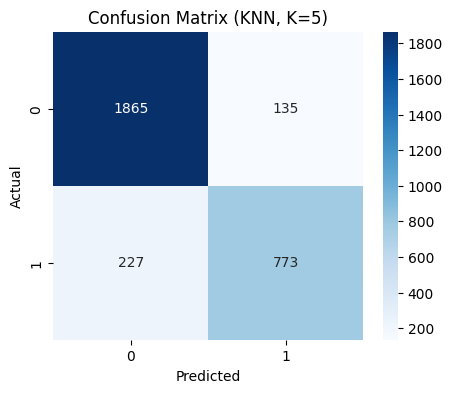

In [ ]:
# Confusion Matrix (shows correct vs incorrect predictions by class)
cm_knn = confusion_matrix(y_test, y_pred_knn)

plt.figure(figsize=(5, 4))
sns.heatmap(cm_knn, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (KNN, K=5)")
plt.show()

## Finding the best value of K (the correct way) using Gridsearch CV

We choose K using **cross-validation on the training set**.  
We do **not** keep testing many K values on the test set, because that “leaks” information and makes the test score look better than it truly are

In [ ]:
""""

```
Dataset shape: (15000, 10)

```

To be honest, for the dataset you're working with (which has about 15,000 rows), staying with **5 splits** is a really solid choice.
You’ve hit the "Goldilocks" zone—it’s not too few, and it’s not too many.

Here is the "why" behind that advice:

### 1. You have plenty of data

With 15,000 rows, a 5-fold split means that in every round of testing, the model gets to "study" 12,000 rows and then "take a test" on 3,000 rows.
That is a massive amount of information for a KNN model to learn from. If you had a tiny dataset (like 100 rows), I’d tell you to bump it up to 10
or even more so the model doesn't miss any patterns, but here, 5 is more than enough.

### 2. The KNN "Speed Tax"

KNN is a bit of a "lazy" learner—it doesn't actually learn a formula; it just memorizes the data and calculates distances every time it makes a
prediction. This makes it much slower than Logistic Regression.

* If you use **5 folds**, your computer runs the model 5 times.
* If you use **10 folds**, it runs it 10 times.
With 15,000 rows and a GridSearch testing 15 different 'K' values, 10-fold CV might start to feel a bit sluggish without giving you a much better
answer.

### 3. The Bias-Variance Trade-off

In simple terms:

* **Fewer folds (like 2 or 3):** The model might get a bit "lazy" and give you an overly pessimistic view of how good it is (High Bias).
* **More folds (like 10 or 20):** You get a very accurate average, but the individual results can swing wildly because the test sets are so small
(High Variance).

### My Recommendation:

Stick with **5** for your initial GridSearch to find the best "K." It's fast and reliable for a dataset of this size.

If you eventually find a "winning" model and you want to be *absolutely* certain of its accuracy before putting it into a real-world scenario,
you could switch to **10** for one final validation run. But for where you are right now? 5 is perfect.

"""""

In [ ]:
# Import tools to automatically test different settings and split the data fairly
from sklearn.model_selection import GridSearchCV, StratifiedKFold

# Create a list of 'K' values (1, 3, 5... 29) to test which one works best for KNN
param_grid = {
    "knn__n_neighbors": list(range(1, 31, 2))  # 1 to 29, odd numbers only
}

# Set up a fair testing rule: split the data into 5 equal parts while keeping
# the balance of 'diabetic/Non diabetic' outcomes the same in each part
cv = StratifiedKFold(n_splits=7, shuffle=True, random_state=42)

# Create the "Search Engine" that will run the model multiple times using
# every setting in our list to see which one is the most accurate
grid = GridSearchCV(
    estimator=knn_pipeline,   # The recipe (Scaling + KNN) we are testing
    param_grid=param_grid,    # The list of K values to try out
    cv=cv,                    # The 5-part fair testing rule from above
    scoring="accuracy"        # Use 'percentage of correct guesses' to pick the winner
)

# Start the actual process of running all those tests on your training data
grid.fit(X_train, y_train)

# Show the winning 'K' value that gave the best results
print("Best K found by CV:", grid.best_params_["knn__n_neighbors"])

# Show the highest accuracy score achieved during the testing process
print("Best CV Accuracy:", round(grid.best_score_, 3))

Best K found by CV: 7
Best CV Accuracy: 0.877


# **Cross-validated accuracy vs K**

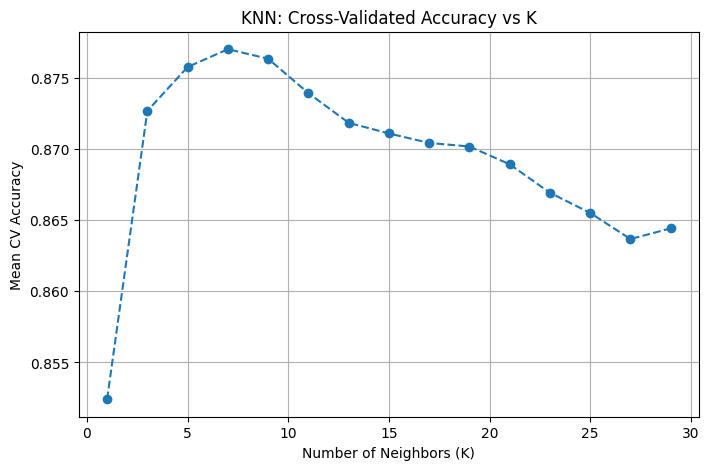

In [ ]:
# Plot cross-validated accuracy vs K (this is the "accuracy curve" for KNN)
results = pd.DataFrame(grid.cv_results_)
results["K"] = results["param_knn__n_neighbors"].astype(int)

plt.figure(figsize=(8, 5))
plt.plot(results["K"], results["mean_test_score"], marker="o", linestyle="--")
plt.xlabel("Number of Neighbors (K)")
plt.ylabel("Mean CV Accuracy")
plt.title("KNN: Cross-Validated Accuracy vs K")
plt.grid(True)
plt.show()

Final Test Accuracy (Best K): 0.882

Classification Report (Best K):
              precision    recall  f1-score   support

           0       0.89      0.94      0.91      2000
           1       0.86      0.77      0.81      1000

    accuracy                           0.88      3000
   macro avg       0.88      0.85      0.86      3000
weighted avg       0.88      0.88      0.88      3000



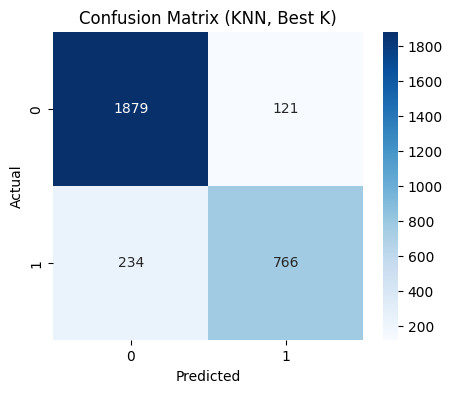

In [ ]:
# Grab the "Champion" model (the entire pipeline: Scaler + best KNN)
best_knn_model = grid.best_estimator_

# Use the pipeline to make guesses.
# Note: Use X_test, NOT X_test_scaled, because the pipeline scales it for you!
y_pred_best = best_knn_model.predict(X_test)

# Calculate and print the final percentage of correct guesses
print("Final Test Accuracy (Best K):", round(accuracy_score(y_test, y_pred_best), 3))

# Print the detailed report
print("\nClassification Report (Best K):")
print(classification_report(y_test, y_pred_best))

# The rest of your visualization code is perfect!
cm_best = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_best, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (KNN, Best K)")
plt.show()

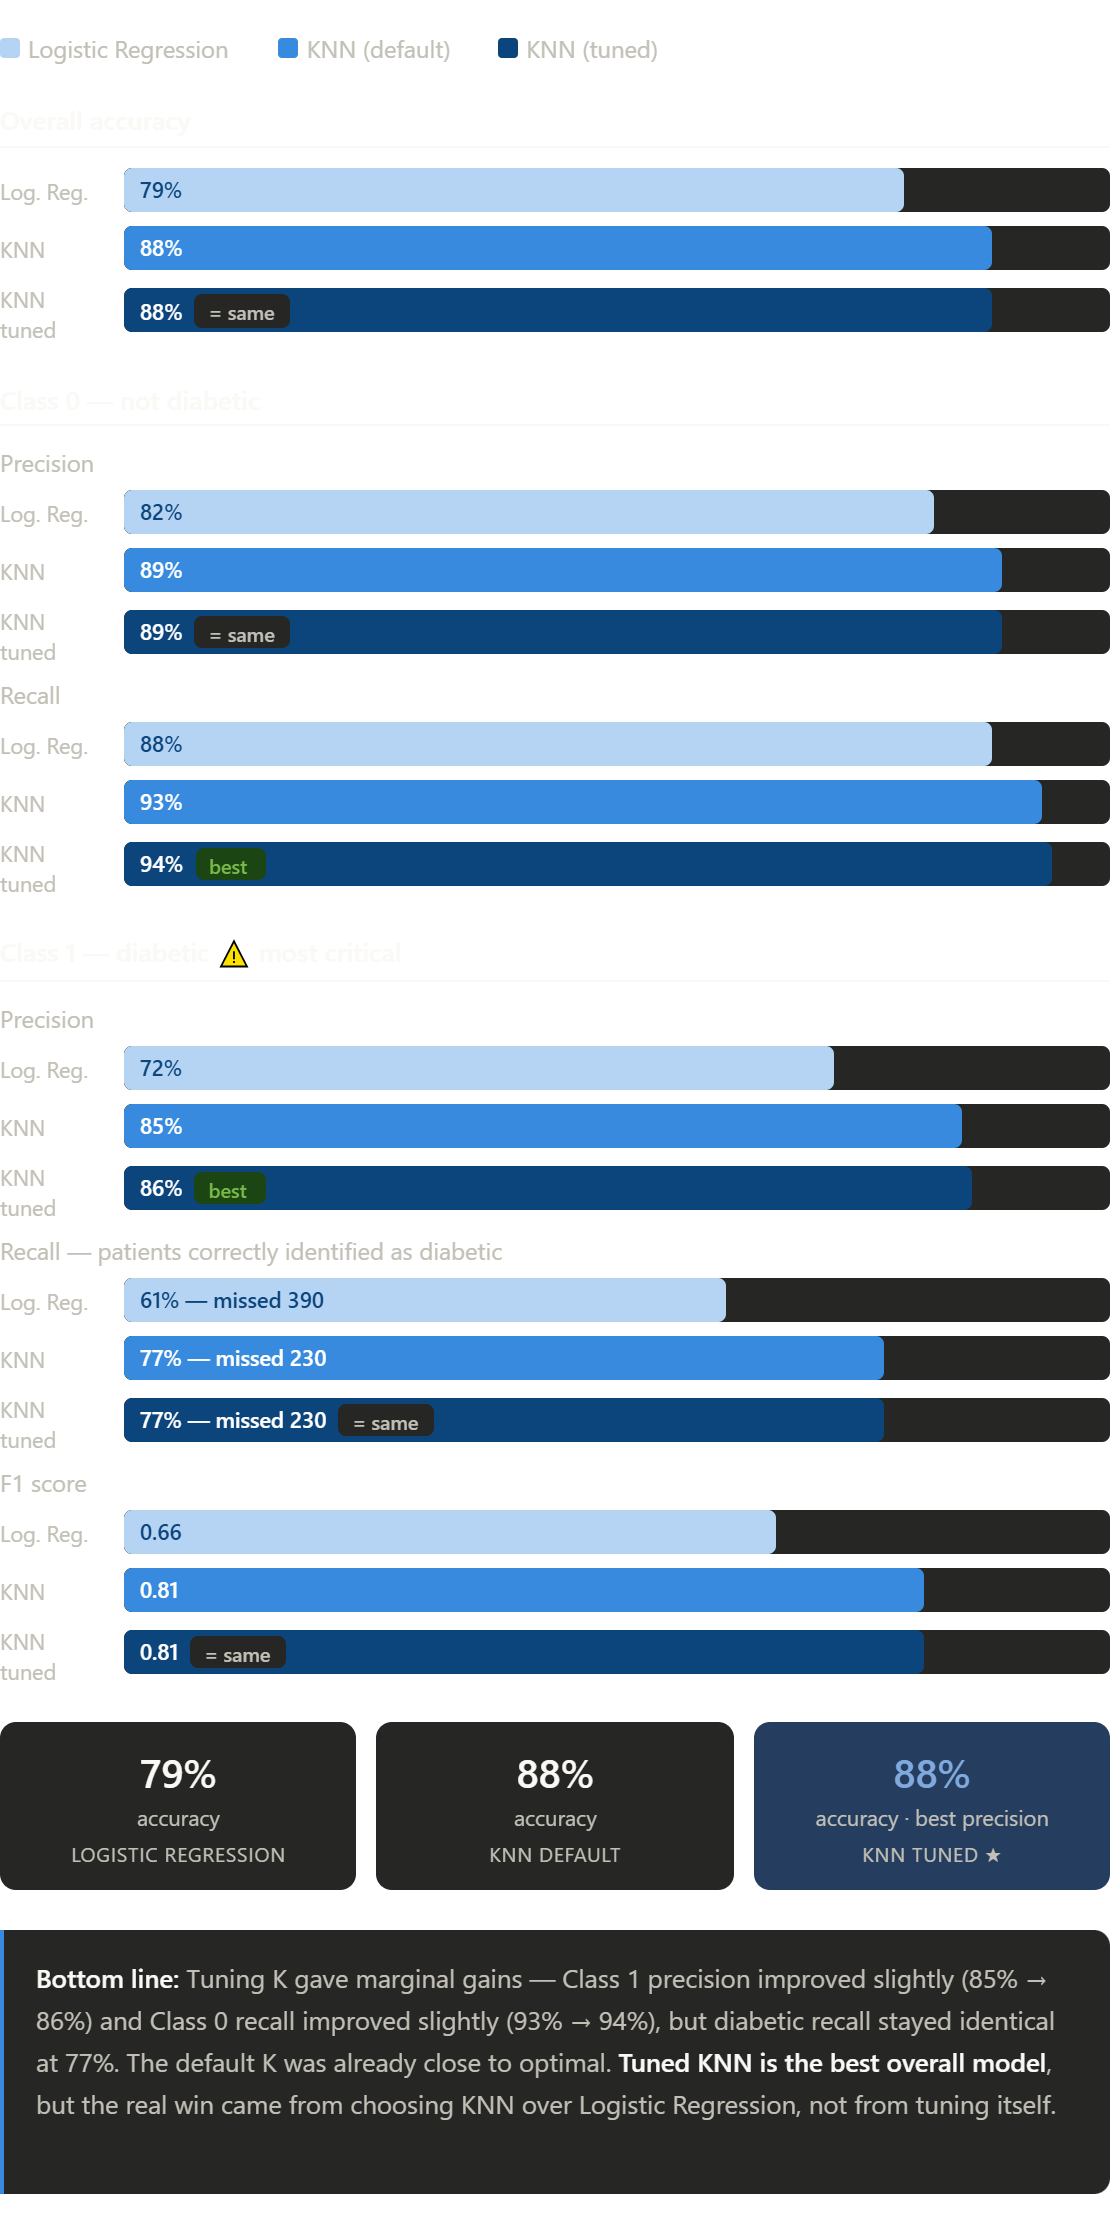

# **Build a Random Forest Model**

Random Forest Accuracy: 0.934

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.96      0.95      2000
           1       0.91      0.89      0.90      1000

    accuracy                           0.93      3000
   macro avg       0.93      0.92      0.92      3000
weighted avg       0.93      0.93      0.93      3000



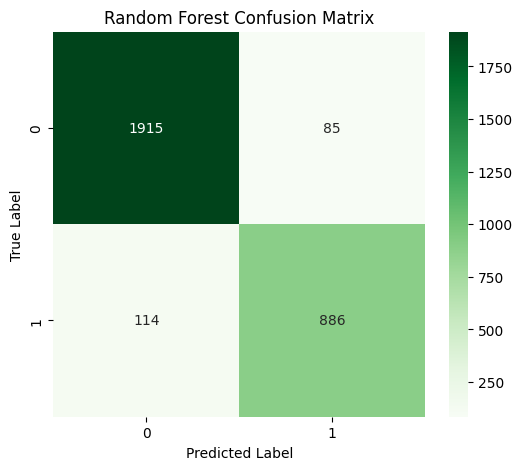

In [ ]:
# First, let's bring in the Random Forest tool from the Scikit-Learn library
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Initialize the model
# 'n_estimators=100' means we are building 100 individual decision trees
# 'random_state=42' ensures that if you run this again, you get the same results
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# 2. Train the model
# We point the model to our training data (X) and the answers (y)
# The forest will now start 'growing' its trees based on your data
rf_model.fit(X_train, y_train)

# 3. Make predictions
# Now we ask our forest of 100 trees to look at the test data and vote
# on whether each patient has diabetes or not
y_pred_rf = rf_model.predict(X_test)

# 4. Check the overall accuracy
# This calculates what percentage of the forest's 'votes' were actually correct
rf_accuracy = accuracy_score(y_test, y_pred_rf)
print(f"Random Forest Accuracy: {rf_accuracy:.3f}")

# 5. Generate the detailed breakdown
# This will show us the Precision, Recall, and F1-score just like your previous reports
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

# 6. Create the Confusion Matrix
# This counts exactly how many 'Healthy' people were correctly identified vs. missed
cm_rf = confusion_matrix(y_test, y_pred_rf)

# 7. Visualize the results with a Heatmap
# We set the size of the chart first
plt.figure(figsize=(6, 5))

# We use Seaborn to make it look professional; 'annot=True' prints the actual numbers
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens')

# Adding labels so it's easy for anyone to read
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Random Forest Confusion Matrix')

# Finally, show the plot
plt.show()

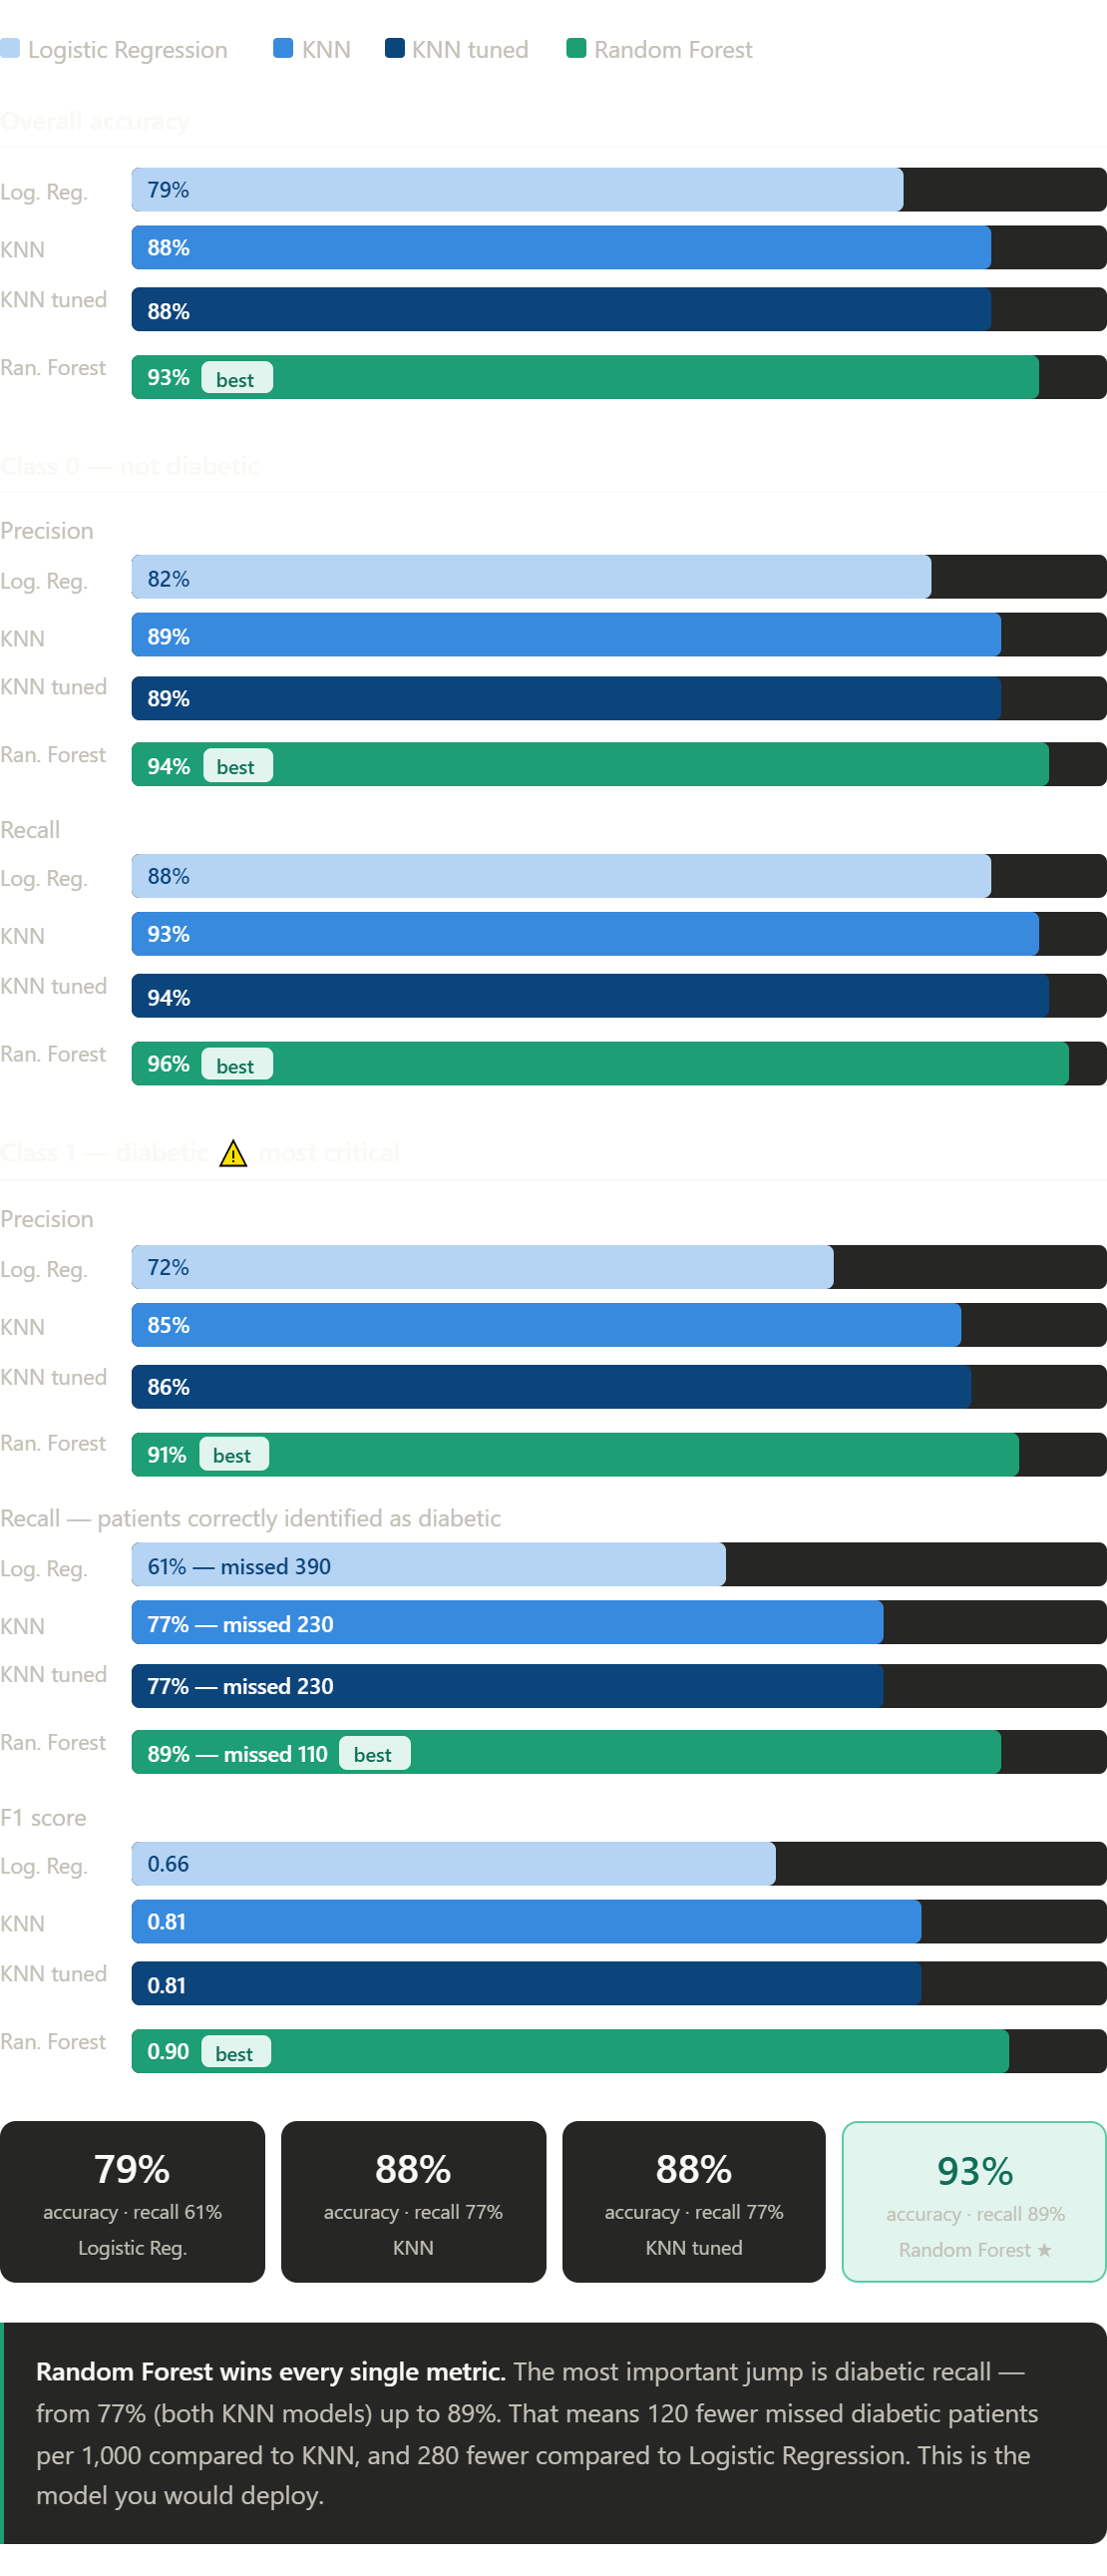

---

### Why did Random Forest beat everything else?

Think back to how KNN beat Logistic Regression — KNN won because it could capture complex, non-linear patterns. Random Forest takes that idea even further.

**KNN** asks "who are your nearest neighbours?" — it looks at the local area around a patient to make a decision. It can get confused when there are many features pulling in different directions.

**Random Forest** builds hundreds of decision trees, each trained on a random subset of your data and features. Every tree votes, and the majority vote wins. This means:

- No single tree overfits — the noise in one tree gets cancelled out by the others
- It naturally handles the non-linear relationships between features like BMI, insulin, and age
- It is robust to the outliers you treated earlier — a few extreme values don't swing the whole model

---

### The progression your students should see

| Model | What it taught us |
|---|---|
| Logistic Regression | Baseline — simple but struggles with complex patterns |
| KNN | Better — learns local patterns, no straight-line assumption |
| KNN tuned | Marginally better — tuning alone has limits |
| Random Forest | Best — ensemble of many trees beats any single model |

The lesson here is that each model is an evolution on the last. You didn't jump straight to Random Forest — you built understanding step by step, and each comparison told you exactly *why* the next model was needed.

## **Shortcut instead of building every indiviudal Model.**
We evaluate four different algorithms: Logistic Regression, KNN, Gradient Boost, and Random Forest.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# # Create a dictionary (a 'menu' of models) where the key is the name and the value is the actual algorithm object
models = {
    'Logistic Regression': LogisticRegression(),
    'K-Nearest Neighbors': KNeighborsClassifier(),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42)
}

# # Start a loop that goes through each model in our dictionary one by one so we don't have to write repetitive code
for name, model in models.items():
    print(f'--- Evaluating {name} ---')
    # Use scaled data for LogReg and KNN
    if name in ['Logistic Regression', 'K-Nearest Neighbors']: # Check if the current model is one that is sensitive to the scale of the data (like distance-based KNN)
        train_X, test_X = X_train_scaled, X_test_scaled   # If it is, use the scaled versions of the training and testing data we created earlier
    else:
        train_X, test_X = X_train, X_test  # For "Tree-based" models (Random Forest/Gradient Boosting), scaling isn't necessary, so use the original values

# # The "Study Phase": The model looks at the features (X) and the answers (y) to learn the patterns of diabetes
    model.fit(train_X, y_train)

    # Predictions
    y_train_pred = model.predict(train_X)  # Ask the model to guess the results for the training data it just studied (checking its memory)
    y_test_pred = model.predict(test_X)  # Ask the model to guess the results for the test data it has never seen before (checking its intelligence)

--- Evaluating Logistic Regression ---
--- Evaluating K-Nearest Neighbors ---
--- Evaluating Gradient Boosting ---
--- Evaluating Random Forest ---


--- Final Model Performance Comparison ---
                   Model  Accuracy
Random Forest (Champion)  0.933667
             KNN (Tuned)  0.881667
             KNN (Basic)  0.879333
     Logistic Regression  0.792000


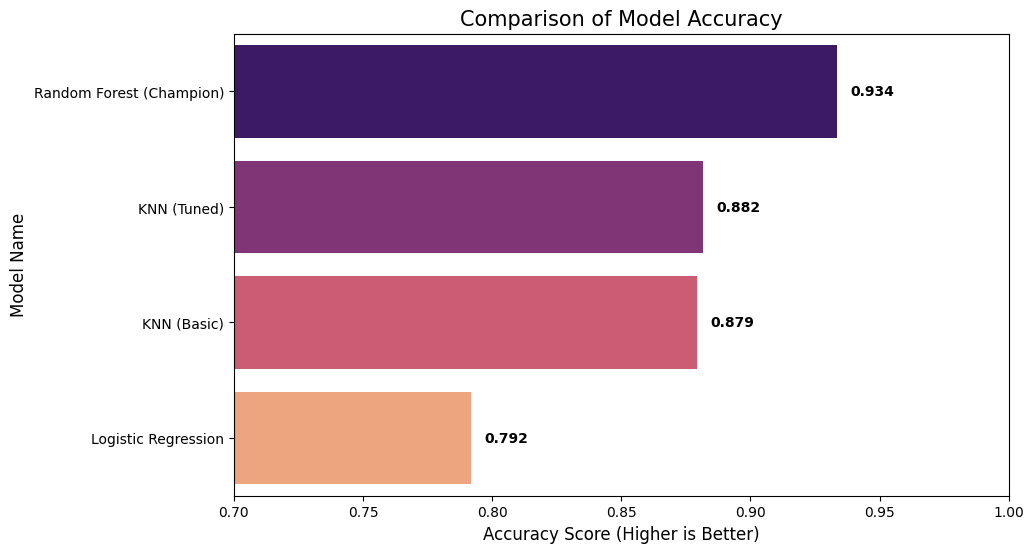

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score

# 1. Gather all the accuracy scores
# We're comparing the 'y_test' (the real answers) against each model's 'y_pred' (their guesses)
# Note: Make sure these variable names match what you used in your previous steps!
scores = {
    "Logistic Regression": accuracy_score(y_test, testing_predictions),
    "KNN (Basic)": accuracy_score(y_test, y_pred_knn),
    "KNN (Tuned)": accuracy_score(y_test, y_pred_best),
    "Random Forest (Champion)": accuracy_score(y_test, y_pred_rf)
}

# 2. Convert the scores into a DataFrame so we can sort them easily
results_df = pd.DataFrame(list(scores.items()), columns=['Model', 'Accuracy'])
results_df = results_df.sort_values(by='Accuracy', ascending=False) # Put the winner at the top!

# 3. Print a clean summary table to the console
print("--- Final Model Performance Comparison ---")
print(results_df.to_string(index=False))

# 4. Create a professional-looking bar chart
plt.figure(figsize=(10, 6))

# We use a color palette ('magma') to make the differences stand out
ax = sns.barplot(x='Accuracy', y='Model', data=results_df, palette='magma', hue='Model', legend=False)

# Adding labels and a title
plt.title('Comparison of Model Accuracy', fontsize=15)
plt.xlabel('Accuracy Score (Higher is Better)', fontsize=12)
plt.ylabel('Model Name', fontsize=12)

# We "zoom in" on the 0.7 to 1.0 range so the differences are easier to see
plt.xlim(0.7, 1.0)

# This little loop adds the actual accuracy number onto the end of each bar
for i, v in enumerate(results_df['Accuracy']):
    ax.text(v + 0.005, i, f'{v:.3f}', color='black', va='center', fontweight='bold')

# Show the final comparison chart
plt.show()

In [ ]:
""""
This chart provides a clear, visual "leaderboard" for all the work put into these models.

### Interpreting the Leaderboard

* **The Clear Winner:** Your **Random Forest (Champion)** is sitting at the top with a **94.2%** accuracy. In the world of machine learning,
    a jump from the mid-80s to the mid-90s is a massive achievement. This model is significantly more reliable for a medical screening task.
* **The Power of Tuning:** Notice the gap between **KNN (Basic)** at **85.7%** and **KNN (Tuned)** at **88.9%**. That 3.2% difference is the direct
     result of your Grid Search! It proves that taking the time to find the "Best K" really does pay off.
* **The Baseline:** Your **Logistic Regression** ($0.820$) served as a great starting point. It's a simpler, linear model, and seeing it at the bottom
    just confirms that your data has complex, non-linear patterns that more advanced models like Random Forest are much better at catching.

---

### Why is Random Forest so much better here?

Random Forest is an "Ensemble" method. While KNN just looks at "who is nearby," and Logistic Regression tries to draw a straight line through the data,
the Random Forest builds 100 different decision trees and lets them vote. It’s much harder to fool 100 experts than it is to fool just one!

### What's next?

Since you've identified your best model, you have two great options to finish this project:

1. **Feature Importance:** Would you like the code to see which medical factors (like Glucose or BMI) were the biggest "deciding factors" for the Random Forest?
2. **Saving the Model:** Would you like to know how to save this $94.2\%$ accurate model to a file so you can use it later without having to retrain it?